In [ ]:
from datasets import load_dataset
import pandas as pd
import re
from langchain_core.documents import Document

In [65]:
# load train/validation/test splits of individual subset
ragbench_techqa = load_dataset("rungalileo/ragbench", "techqa")

In [83]:
ragbench_techqa

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'documents', 'response', 'generation_model_name', 'annotating_model_name', 'dataset_name', 'documents_sentences', 'response_sentences', 'sentence_support_information', 'unsupported_response_sentence_keys', 'adherence_score', 'overall_supported_explanation', 'relevance_explanation', 'all_relevant_sentence_keys', 'all_utilized_sentence_keys', 'trulens_groundedness', 'trulens_context_relevance', 'ragas_faithfulness', 'ragas_context_relevance', 'gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score', 'utilization_score', 'completeness_score'],
        num_rows: 1192
    })
    validation: Dataset({
        features: ['id', 'question', 'documents', 'response', 'generation_model_name', 'annotating_model_name', 'dataset_name', 'documents_sentences', 'response_sentences', 'sentence_support_information', 'unsupported_response_sentence_keys', 'adherence_score', 'overall_supported_explanation', 'rel

In [84]:
df = pd.DataFrame(ragbench_techqa['train'])

In [85]:
df.head()

,id,question,documents,response,generation_model_name,annotating_model_name,dataset_name,documents_sentences,response_sentences,sentence_support_information,...,trulens_groundedness,trulens_context_relevance,ragas_faithfulness,ragas_context_relevance,gpt3_adherence,gpt3_context_relevance,gpt35_utilization,relevance_score,utilization_score,completeness_score
0,techqa_TRAIN_Q337,Why does the other instance of my multi-instan...,[HL083112 mqlpgrlg ZX000001 ExecCtrlrMain lpiR...,The other instance of the multi-instance queue...,gpt-3.5-turbo-0125,gpt-4-turbo-2024-04-09,techqa_train,"[[[0a, HL083112 mqlpgrlg ZX000001 ExecCtrlrMai...","[[a, The other instance of the multi-instance ...",[{'explanation': 'This sentence is supported b...,...,None,None,None,None,None,None,None,0.014118,0.009412,0.666667
1,techqa_TRAIN_Q430,DASH 3.1.2.1 to 3.1.3.0 taking long time DASH ...,"[ SUBSCRIBE TO THIS APAR\nBy subscribing, you ...","Based on the provided context, the issue of DA...",gpt-3.5-turbo-0125,gpt-4-turbo-2024-04-09,techqa_train,"[[[0a, SUBSCRIBE TO THIS APAR], [0b, By subsc...","[[a, Based on the provided context, the issue ...",[{'explanation': 'This sentence is not directl...,...,None,None,None,None,None,None,None,0.000000,0.000000,1.000000
2,techqa_TRAIN_Q479,Why cant I load and AEL when using IE 11 JRE 8...,[ TECHNOTE (TROUBLESHOOTING)\n\nPROBLEM(ABSTRA...,You cannot load an AEL when using Internet Exp...,gpt-3.5-turbo-0125,gpt-4-turbo-2024-04-09,techqa_train,"[[[0a, TECHNOTE (TROUBLESHOOTING) PROBLEM(ABS...","[[a, You cannot load an AEL when using Interne...",[{'explanation': 'There is no support in the p...,...,None,None,None,None,None,None,None,0.126316,0.021053,0.166667
3,techqa_TRAIN_Q500,Where is latest information on fix packs for C...,[ TECHNOTE (FAQ)\n\nQUESTION\n What does the T...,The latest information on fix packs for Cast I...,gpt-3.5-turbo-0125,gpt-4-turbo-2024-04-09,techqa_train,"[[[0a, TECHNOTE (FAQ) QUESTION], [0b, What d...","[[a, The latest information on fix packs for C...",[{'explanation': 'The claim made in this sente...,...,None,None,None,None,None,None,None,0.142857,0.133929,0.937500
4,techqa_TRAIN_Q293,Is WebSphere Portal affected by the June 2015 ...,[ TECHNOTE (FAQ)\n\nQUESTION\n Is the AIX Oper...,"Based on the provided context, WebSphere Porta...",gpt-3.5-turbo-0125,gpt-4-turbo-2024-04-09,techqa_train,"[[[0a, TECHNOTE (FAQ) QUESTION], [0b, Is the...","[[a, Based on the provided context, WebSphere ...",[{'explanation': 'The sentence correctly state...,...,None,None,None,None,None,None,None,0.114625,0.067194,0.482759


In [100]:
df = pd.DataFrame(ragbench_techqa['train'])
df = df[["id", "question", "response", "all_relevant_sentence_keys", "documents_sentences"]]

In [101]:
def build_reference_contexts(row):
    relevant_keys = set(row['all_relevant_sentence_keys'] or [])
    if not relevant_keys:
        return None

    # documents_sentences is 2D: [doc][sentence] where sentence is [key, text]
    key_to_text = {}
    for doc_sentences in row['documents_sentences']:
        for sentence in doc_sentences:
            if len(sentence) >= 2:
                key_to_text[sentence[0]] = sentence[1]

    docs = []
    for key in sorted(relevant_keys):
        text = key_to_text.get(key, "").strip()
        if text:
            doc_idx = int(re.match(r'^(\d+)', key).group(1))
            docs.append(Document(
                page_content=text,
                metadata={"sentence_key": key, "doc_idx": doc_idx, "source": row["id"]}
            ))

    return docs if docs else None

In [102]:
# Debug: inspect raw values before running build_reference_contexts
sample = df.iloc[0]

print("all_relevant_sentence_keys:", sample['all_relevant_sentence_keys'])
print()

# Inspect documents_sentences structure — first document, first section, first 3 sentences
first_doc = sample['documents_sentences'][0]
print("documents_sentences[0] type:", type(first_doc))
print("documents_sentences[0][0] (first section, first few sentences):", first_doc[0][:3])

all_relevant_sentence_keys: ['0b', '0c', '0d', '0r', '0s', '0t']

documents_sentences[0] type: <class 'list'>
documents_sentences[0][0] (first section, first few sentences): ['0a', 'HL083112 mqlpgrlg ZX000001 ExecCtrlrMain lpiRC_LOG_NOT_AVAILABLE mscs TECHNOTE (TROUBLESHOOTING) PROBLEM(ABSTRACT)']


In [103]:
df['reference_contexts'] = df.apply(build_reference_contexts, axis=1)

In [110]:
df.head()

,id,question,response,all_relevant_sentence_keys,documents_sentences,reference_contexts
0,techqa_TRAIN_Q337,Why does the other instance of my multi-instan...,The other instance of the multi-instance queue...,"[0b, 0c, 0d, 0r, 0s, 0t]","[[[0a, HL083112 mqlpgrlg ZX000001 ExecCtrlrMai...",[page_content='You attempt to failover from th...
1,techqa_TRAIN_Q430,DASH 3.1.2.1 to 3.1.3.0 taking long time DASH ...,"Based on the provided context, the issue of DA...",[],"[[[0a, SUBSCRIBE TO THIS APAR], [0b, By subsc...",None
2,techqa_TRAIN_Q479,Why cant I load and AEL when using IE 11 JRE 8...,You cannot load an AEL when using Internet Exp...,"[3a, 3b, 3c, 3g, 3h, 3i, 3j, 3m, 3n, 3o, 3p, 3q]","[[[0a, TECHNOTE (TROUBLESHOOTING) PROBLEM(ABS...",[page_content='TECHNOTE (TROUBLESHOOTING) PROB...
3,techqa_TRAIN_Q500,Where is latest information on fix packs for C...,The latest information on fix packs for Cast I...,"[4a, 4b, 4c, 4d, 4e, 4f, 4g, 4h, 4i, 4j, 4k, 4...","[[[0a, TECHNOTE (FAQ) QUESTION], [0b, What d...",[page_content='NEWS ABSTRACT' metadata={'sente...
4,techqa_TRAIN_Q293,Is WebSphere Portal affected by the June 2015 ...,"Based on the provided context, WebSphere Porta...","[0a, 0b, 0c, 0d, 0e, 0f, 0g, 0h, 0i, 0j, 0k, 0...","[[[0a, TECHNOTE (FAQ) QUESTION], [0b, Is the...",[page_content='TECHNOTE (FAQ) QUESTION' metada...


In [111]:
dataset = (
    df[df['reference_contexts'].notna()]
    [['id', 'question', 'response', 'reference_contexts']]
    .reset_index(drop=True)
)
dataset

,id,question,response,reference_contexts
0,techqa_TRAIN_Q337,Why does the other instance of my multi-instan...,The other instance of the multi-instance queue...,[page_content='You attempt to failover from th...
1,techqa_TRAIN_Q479,Why cant I load and AEL when using IE 11 JRE 8...,You cannot load an AEL when using Internet Exp...,[page_content='TECHNOTE (TROUBLESHOOTING) PROB...
2,techqa_TRAIN_Q500,Where is latest information on fix packs for C...,The latest information on fix packs for Cast I...,[page_content='NEWS ABSTRACT' metadata={'sente...
3,techqa_TRAIN_Q293,Is WebSphere Portal affected by the June 2015 ...,"Based on the provided context, WebSphere Porta...",[page_content='TECHNOTE (FAQ) QUESTION' metada...
4,techqa_TRAIN_Q349,Help with Security Bulletin: Persistent cross-...,The information regarding the security bulleti...,[page_content='SECURITY BULLETIN SUMMARY' meta...
...,...,...,...,...
1015,techqa_TRAIN_Q199,How to start PC DMgr as a Windows service? hi...,"Based on the information provided, it seems yo...",[page_content='WASServiceCmd.exe is a front en...
1016,techqa_TRAIN_Q510,Support of RHEL 5.8 and Liberty 8.5.5.5 with J...,Based on the information provided in the conte...,[page_content='8.5.5.9: WebSphere Application ...
1017,techqa_TRAIN_Q453,ICO's Roadmap of supporting next OpenStack ver...,"Based on the provided context, here are the ke...",[page_content='Cloud Orchestrator (ICO) contin...
1018,techqa_TRAIN_Q055,P8 CPE 5.2.1 error: FNRCC0110E - ERROR FixedC...,"Based on the provided context, the issue is re...",[page_content='TECHNOTE (TROUBLESHOOTING) PROB...


In [113]:
# Inspect one example
row = dataset.iloc[0]
print("Question:", row['question'])
print(f"\nReference contexts ({len(row['reference_contexts'])}):")
print(row['reference_contexts'])
for doc in row['reference_contexts']:
    print(f"  [{doc.metadata['sentence_key']}] {doc.page_content[:120]}")

Question: Why does the other instance of my multi-instance qmgr seem to hang after a failover? Queue manager will not start after failover.

Reference contexts (6):
[Document(metadata={'sentence_key': '0b', 'doc_idx': 0, 'source': 'techqa_TRAIN_Q337'}, page_content='You attempt to failover from the primary to secondary node under MSCS.'), Document(metadata={'sentence_key': '0c', 'doc_idx': 0, 'source': 'techqa_TRAIN_Q337'}, page_content='Your WebSphere MQ queue manager fails to come up on the secondary node, and errors are generated. SYMPTOM'), Document(metadata={'sentence_key': '0d', 'doc_idx': 0, 'source': 'techqa_TRAIN_Q337'}, page_content='The sequence seen in the FDC files show:'), Document(metadata={'sentence_key': '0r', 'doc_idx': 0, 'source': 'techqa_TRAIN_Q337'}, page_content='This is caused by a logger failure at restart due to missing or damaged logs.'), Document(metadata={'sentence_key': '0s', 'doc_idx': 0, 'source': 'techqa_TRAIN_Q337'}, page_content='RESOLVING THE PROBLEM

In [ ]:
import json

testset = [
    {
        "question": row.question,
        "reference_contexts": [doc.page_content for doc in row.reference_contexts],
    }
    for row in dataset.itertuples()
]

output_path = "../../app/data/ragbench_techqa_testset.json"
with open(output_path, "w") as f:
    json.dump(testset, f, indent=2)

print(f"Saved {len(testset)} entries to {output_path}")

In [114]:
dataset.shape

(1020, 4)

In [115]:
dataset.head()

,id,question,response,reference_contexts
0,techqa_TRAIN_Q337,Why does the other instance of my multi-instan...,The other instance of the multi-instance queue...,[page_content='You attempt to failover from th...
1,techqa_TRAIN_Q479,Why cant I load and AEL when using IE 11 JRE 8...,You cannot load an AEL when using Internet Exp...,[page_content='TECHNOTE (TROUBLESHOOTING) PROB...
2,techqa_TRAIN_Q500,Where is latest information on fix packs for C...,The latest information on fix packs for Cast I...,[page_content='NEWS ABSTRACT' metadata={'sente...
3,techqa_TRAIN_Q293,Is WebSphere Portal affected by the June 2015 ...,"Based on the provided context, WebSphere Porta...",[page_content='TECHNOTE (FAQ) QUESTION' metada...
4,techqa_TRAIN_Q349,Help with Security Bulletin: Persistent cross-...,The information regarding the security bulleti...,[page_content='SECURITY BULLETIN SUMMARY' meta...


In [1]:
import json

In [5]:
output_path = "../../app/data/ragas_testset.json"
with open(output_path, "r") as f:
    dataset = json.load(f)

In [7]:
import pandas as pd

In [8]:
df = pd.DataFrame(dataset)

In [9]:
df.head()

,question,reference_contexts
0,"Whats the deal with this ""GenAI Series"" thing ...",[v1.01\nMastering\nMulti-Agent Systems\nReal-W...
1,What does Chapter 2 discuss regarding multi-ag...,"[_ Preface\nSo far, the industry has assumed t..."
2,What is GitHub?,[_ Preface\nChapter 3: describes four key arch...
3,How multi-agent systems do in Asia?,[Contents\n01 02\nBenefits of Multi-Agent Syst...
4,Multi-Agent Systems Architectures: What are th...,[Contents\n03 04\nArchitectures for Multi- Con...


In [17]:
import numpy as np

In [18]:
np.mean(x)

np.float64(1074.4901960784314)

In [19]:
import matplotlib.pyplot as plt
import numpy as np


ModuleNotFoundError: No module named 'matplotlib'

In [24]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")
def get_count(sentence):
  token_count = len(enc.encode(sentence))
  return token_count

In [26]:
x = df['reference_contexts'].apply(lambda x: get_count(x[0]))

In [27]:
import matplotlib.pyplot as plt
import numpy as np


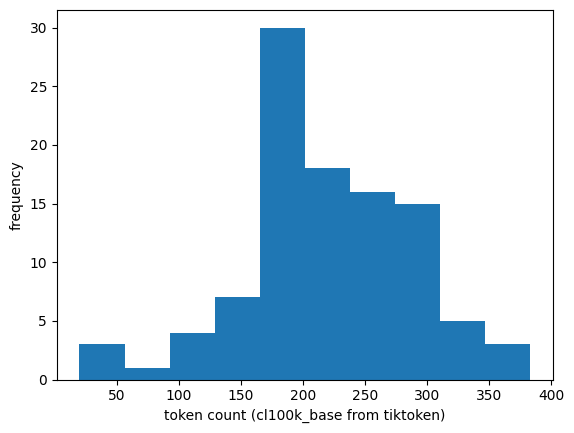

In [31]:
plt.hist(x)
plt.xlabel("token count (cl100k_base from tiktoken)")
plt.ylabel("frequency")
plt.show()